# EDA of titanic dataset
In this notebook we will perform a EDA on the titanic data set to se who live and who dies! :(

## Packages dependencies

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read in data

In [51]:
df = pd.read_csv("Titanic-Dataset.csv")

In [52]:
df.shape

(891, 12)

In [53]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [56]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
df["PassengerId"].nunique()

891

In [58]:
# df = df.drop(columns=["PassengerId"]) # Ansätter df på nytt med en ny dataframe utan PassengerId
# df.drop(columns=["PassengerId"]) # Returnerar en ny dataframe utan PassengerId
df.drop(columns=["PassengerId"], inplace=True)

In [59]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [61]:
print(f"Andel som dog i data set: {549/(342+549):.1%}")

Andel som dog i data set: 61.6%


### Översätter textdata

In [62]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [63]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [64]:
df[df["Age"].isnull()].describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,177.000000,177.000000,177.000000,0.0,177.000000,177.000000,177.000000
mean,0.293785,2.598870,0.299435,NaN,0.564972,0.180791,22.158567
std,0.456787,0.763216,0.459310,NaN,1.626316,0.534145,31.874608
min,0.000000,1.000000,0.000000,NaN,0.000000,0.000000,0.000000
25%,0.000000,3.000000,0.000000,NaN,0.000000,0.000000,7.750000
50%,0.000000,3.000000,0.000000,NaN,0.000000,0.000000,8.050000
75%,1.000000,3.000000,1.000000,NaN,0.000000,0.000000,24.150000
max,1.000000,3.000000,1.000000,NaN,8.000000,2.000000,227.525000


In [65]:
df["Ticket"].nunique()

681

In [66]:
df[df["Ticket"]=="113803"]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1,C123,S
137,0,1,"Futrelle, Mr. Jacques Heath",0,37.0,1,0,113803,53.1,C123,S


In [67]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [68]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [69]:
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

array([[<Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>,
        <Axes: title={'center': 'Sex'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>,
        <Axes: title={'center': 'Embarked'}>, <Axes: >]], dtype=object)

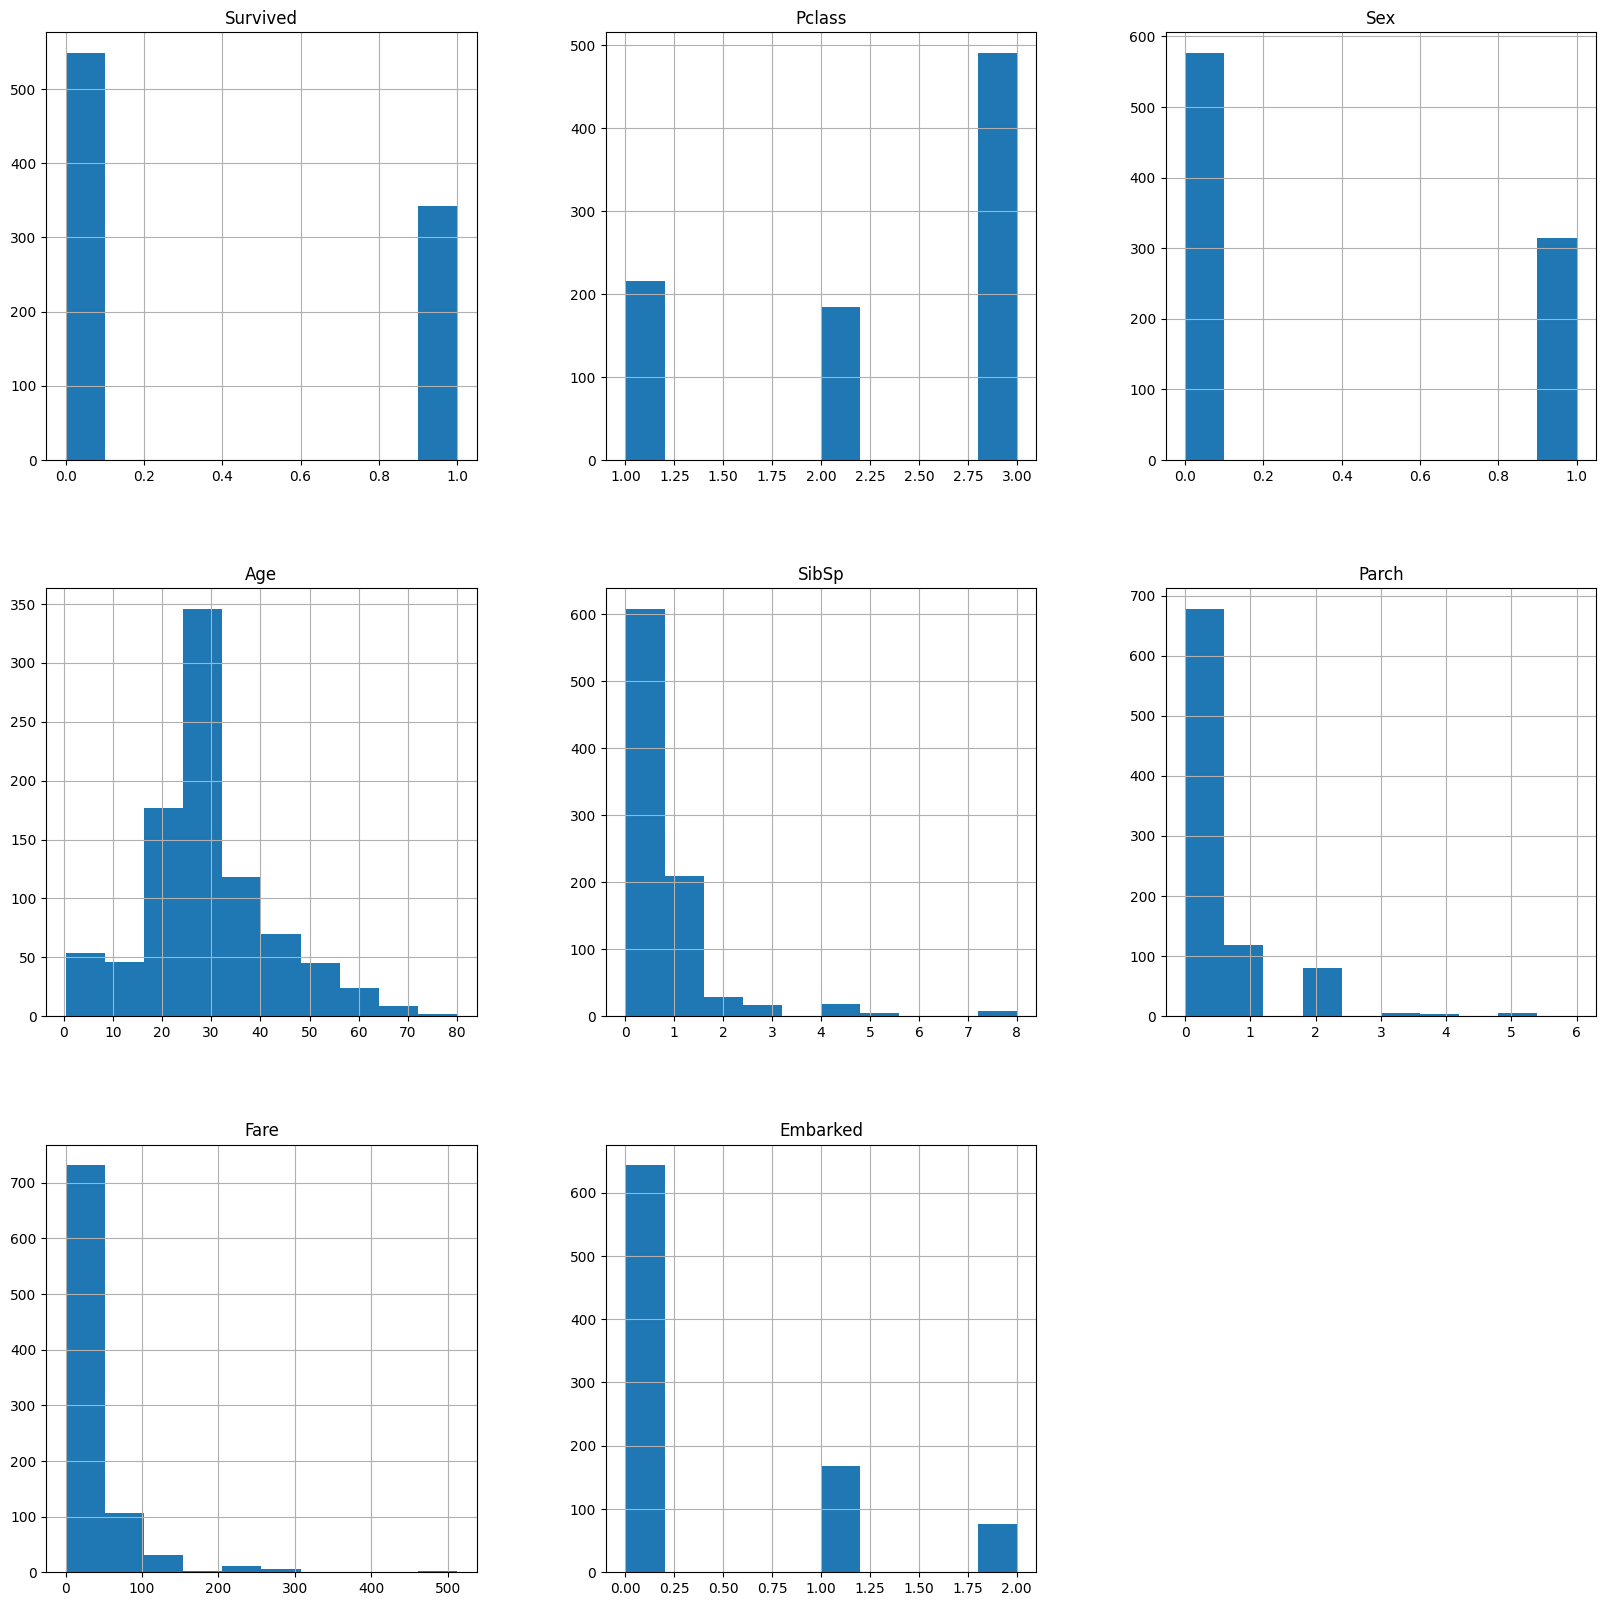

In [75]:
df.hist(figsize=(20, 20))

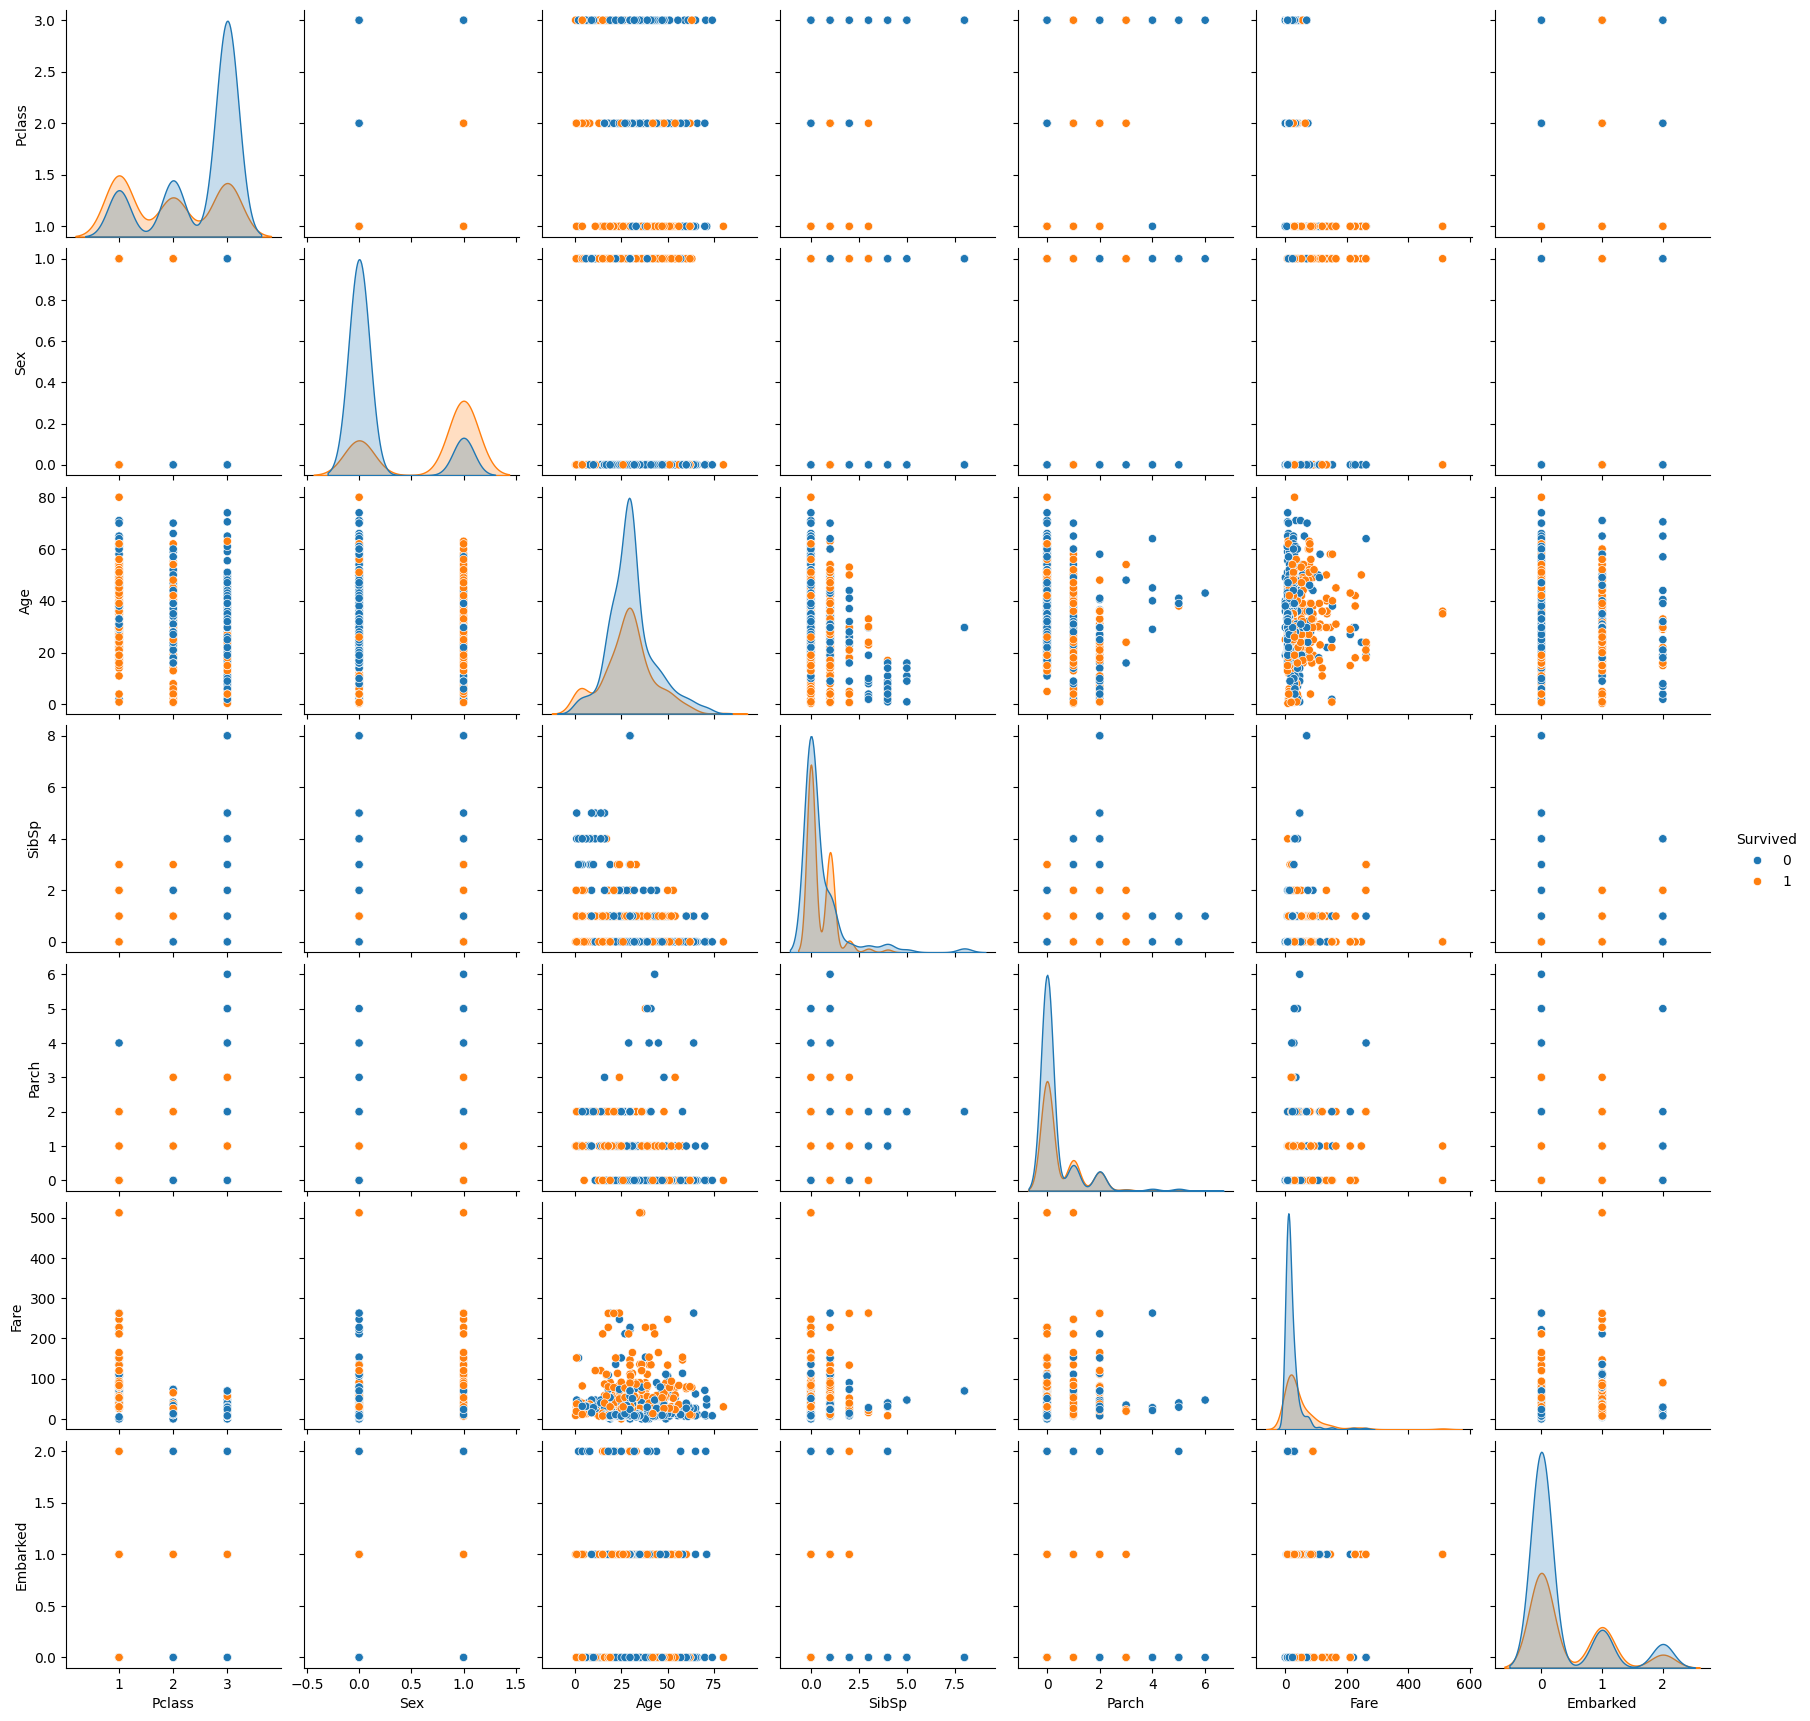

In [71]:
sns.pairplot(df, hue="Survived")

In [72]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<Axes: >

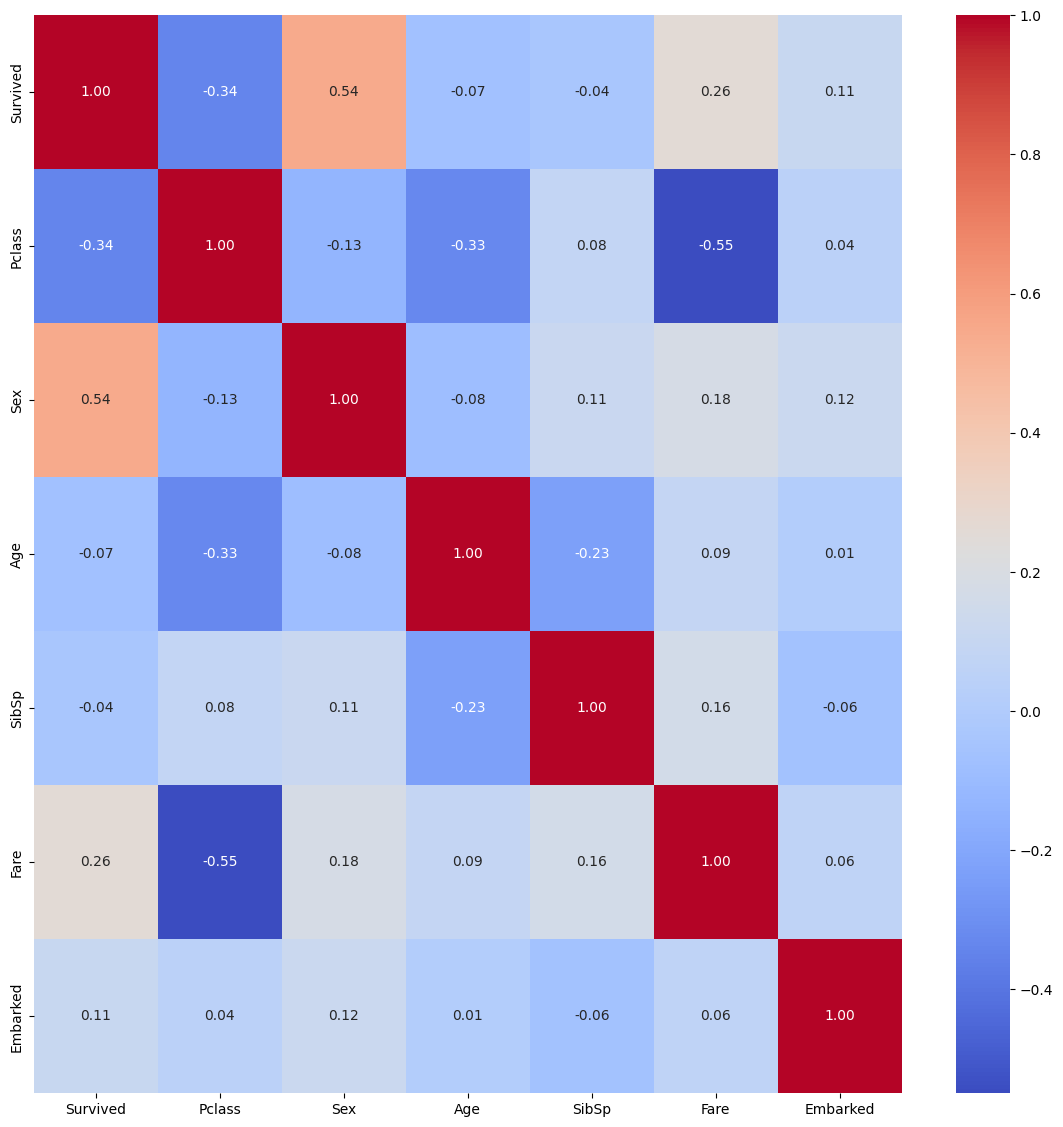

In [73]:
plt.subplots(figsize=(14, 14))
sns.heatmap(
    df.drop(columns=["Name", "Ticket", "Parch", "Cabin"]).corr(),
    cmap = "coolwarm", 
    annot=True, 
    fmt=".2f")

<Axes: >

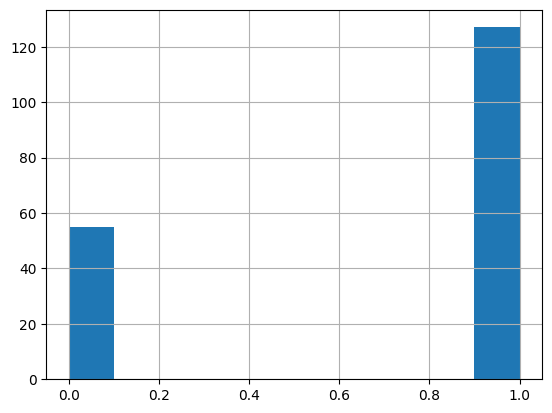

In [74]:
# df[df["A"].str.contains("Hello|Britain")]
df[df["Name"].str.contains("Miss")]["Survived"].hist()